In [1]:
# --- Cell 1: Imports ---
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
from src.splits import stratified_split
from src.experiments import (
    run_computational_benchmark,
    run_hyperparameter_sweep,
    evaluate_baselines,
    evaluate_test_set,
)

In [2]:
# --- Cell 2: Data Preparation ---
# Load the cleaned Titanic feature matrix produced in 01_eda.ipynb
df_clean = pd.read_csv('../data/titanic_cleaned.csv')
X = df_clean.drop(columns=['survived']).values
y = df_clean['survived'].values

print(f'Dataset shape: X={X.shape}, y={y.shape}')
print(f'Overall positive rate: {y.mean():.4f}')

Dataset shape: X=(1309, 10), y=(1309,)
Overall positive rate: 0.3820


In [3]:
# --- Cell 3: Stratified Split (Part 3.1) ---
X_train, X_val, X_test, y_train, y_val, y_test = stratified_split(
    X, y,
    train_frac=0.60,
    val_frac=0.20,
    test_frac=0.20,
    seed=42
)

print(f'Total positive rate:  {y.mean():.4f}')
print(f'Train positive rate:  {y_train.mean():.4f}  (n={len(y_train)})')
print(f'Val positive rate:    {y_val.mean():.4f}  (n={len(y_val)})')
print(f'Test positive rate:   {y_test.mean():.4f}  (n={len(y_test)})')

Total positive rate:  0.3820
Train positive rate:  0.3822  (n=785)
Val positive rate:    0.3817  (n=262)
Test positive rate:   0.3817  (n=262)


Running computational benchmark for N in {100, 500, 1000, 5000, 10000}...


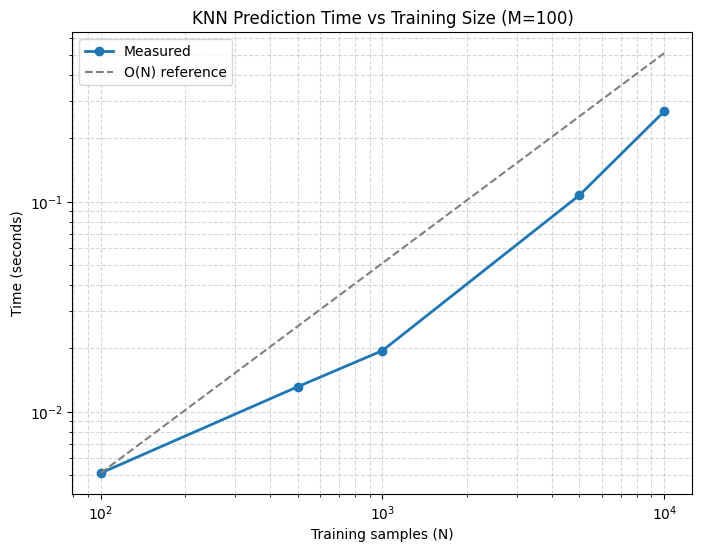

  N=  100 -> 0.00509 s
  N=  500 -> 0.01313 s
  N= 1000 -> 0.01951 s
  N= 5000 -> 0.10725 s
  N=10000 -> 0.26903 s


In [4]:
# --- Cell 4: Computational Benchmark (Part 2.5) ---
print('Running computational benchmark for N in {100, 500, 1000, 5000, 10000}...')
N_values, times = run_computational_benchmark(X_train, y_train, X_test, k=5, m_test=100)

for n, t in zip(N_values, times):
    print(f'  N={n:5d} -> {t:.5f} s')

Running hyperparameter sweep over k...


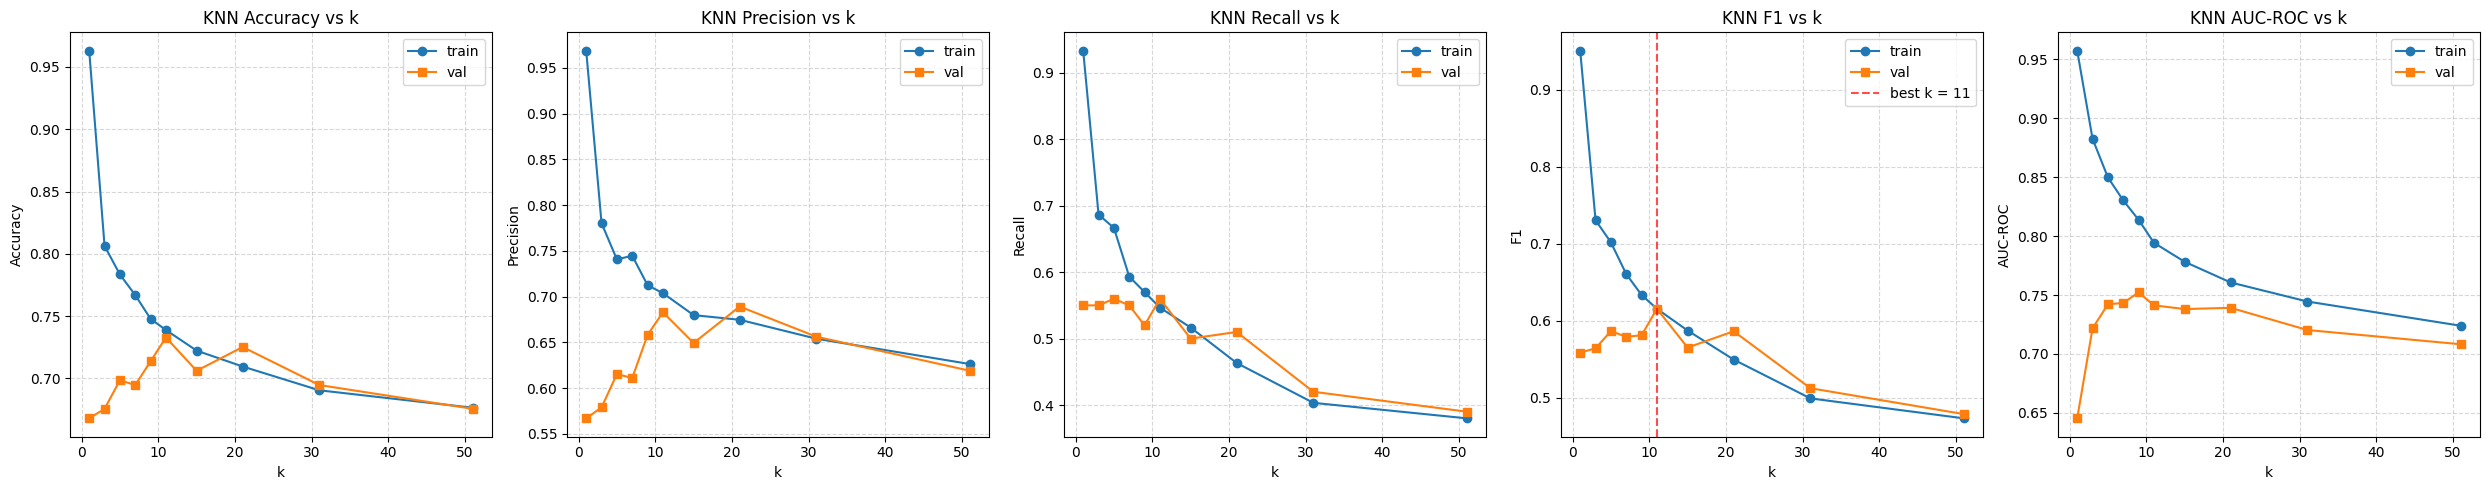


Best k by validation F1: k = 11


In [5]:
# --- Cell 5: Hyperparameter Sweep (Part 3.3) ---
print('Running hyperparameter sweep over k...')
best_k = run_hyperparameter_sweep(X_train, y_train, X_val, y_val)

print(f'\nBest k by validation F1: k = {best_k}')

In [6]:
# --- Cell 6: Baseline Comparison (Part 3.4) ---
print(f'Comparing baselines with best_k = {best_k}...')
baseline_results = evaluate_baselines(X_train, y_train, X_val, y_val, best_k)
display(baseline_results)

Comparing baselines with best_k = 11...


,Accuracy,Precision,Recall,F1 Score,AUC-ROC
Model,,,,,
Custom KNN (k=11),0.732824,0.682927,0.56,0.615385,0.741296
Sklearn KNN (k=11),0.732824,0.682927,0.56,0.615385,0.744105
Majority baseline,0.618321,0.000000,0.00,0.000000,0.500000


In [7]:
# --- Cell 7: Final Test Set Evaluation (Part 3.5) ---
# Run this cell exactly once — do not inspect test results before this point.
print(f'Final test set evaluation with best_k = {best_k}...')
test_results = evaluate_test_set(X_train, y_train, X_test, y_test, best_k)
display(test_results)

Final test set evaluation with best_k = 11...


,Test Score
Metric,
Accuracy,0.721374
Precision,0.642105
Recall,0.610000
F1 Score,0.625641
AUC-ROC,0.757346
